<a href="https://colab.research.google.com/github/floatbeyond/LAVIS/blob/main/BLIP_Diffusion_WORKING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Step 1: Install necessary libraries
# Use -q for quiet installation and correct indentation for line breaks
!pip uninstall -y transformers peft

!pip install -q diffusers==0.29.0 \
             accelerate==0.32.0 \
             torch torchvision \
             huggingface-hub==0.27.1 \
             transformers==4.37.2 \
             peft==0.10.0 \
             tokenizers

Found existing installation: transformers 4.52.2
Uninstalling transformers-4.52.2:
  Successfully uninstalled transformers-4.52.2
Found existing installation: peft 0.15.2
Uninstalling peft-0.15.2:
  Successfully uninstalled peft-0.15.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.0/314.0 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24

### Restart Session here

In [1]:
# Step 1: Import libraries
import torch
from diffusers import BlipDiffusionPipeline
from PIL import Image
import requests
from io import BytesIO
from IPython.display import display
import os

model_id = "Salesforce/blipdiffusion"
device = "cuda" if torch.cuda.is_available() else "cpu"
# For newer diffusers, torch.float16 is generally well-supported on GPU
torch_dtype = torch.float16 if device == "cuda" else torch.float32

blip_diffusion_pipe = None # Initialize

# try:
    # print(f"Attempting to load pipeline with from_pretrained using dtype: {torch_dtype}...")
    # The standard way to load the pipeline
blip_diffusion_pipe = BlipDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch_dtype
)
blip_diffusion_pipe.to(device)
    # print("BLIP-Diffusion pipeline loaded successfully with from_pretrained.")

# except KeyError as e:
#     print(f"KeyError '{e}' encountered with from_pretrained even on diffusers {diffusers.__version__}.")
#     print("This is unexpected for newer versions but might indicate a persistent config issue with this specific model.")
#     print("If this happens, manual component loading might still be needed.")
#     blip_diffusion_pipe = None # Ensure it's None so generation step doesn't run
#     # If you want to try manual loading as a fallback, you'd put that logic here or in a subsequent cell.
#     # For now, we'll just report the error.
#     import traceback
#     traceback.print_exc()

# except Exception as e:
#     print(f"An unexpected error occurred during model loading: {e}")
#     import traceback
#     traceback.print_exc()
#     blip_diffusion_pipe = None # Ensure it's None
#     raise # Re-raise other unexpected errors

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.wa

model_index.json:   0%|          | 0.00/682 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors not found


...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--Salesforce--blipdiffusion/snapshots/b7479a77cc10d8a51aad9638b5bd3f83a5692183/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--Salesforce--blipdiffusion/snapshots/b7479a77cc10d8a51aad9638b5bd3f83a5692183/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--Salesforce--blipdiffusion/snapshots/b7479a77cc10d8a51aad9638b5bd3f83a5692183/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--Salesforce--blipdiffusion/snapshots/b7479a77cc10d8a51aad9638b5bd3f83a5692183/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


BlipDiffusionPipeline {
  "_class_name": "BlipDiffusionPipeline",
  "_diffusers_version": "0.29.0",
  "_name_or_path": "Salesforce/blipdiffusion",
  "ctx_begin_pos": 2,
  "image_processor": [
    "blip_diffusion",
    "BlipImageProcessor"
  ],
  "mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "qformer": [
    "blip_diffusion",
    "Blip2QFormerModel"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "text_encoder": [
    "blip_diffusion",
    "ContextCLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [2]:
from google.colab import files
import os

print("Please upload your CONDITIONAL image (e.g., the teddy bear):")
uploaded_conditional = files.upload()

# Get the filename of the uploaded conditional image
# It will be a dictionary, so we take the first key
conditional_image_filename = None
if uploaded_conditional:
    conditional_image_filename = list(uploaded_conditional.keys())[0]
    print(f"Uploaded conditional image: '{conditional_image_filename}'")
else:
    print("No conditional image was uploaded.")

print("\nPlease upload your REFERENCE image (e.g., the guitar):")
uploaded_reference = files.upload()

# Get the filename of the uploaded reference image
reference_image_filename = None
if uploaded_reference:
    reference_image_filename = list(uploaded_reference.keys())[0]
    print(f"Uploaded reference image: '{reference_image_filename}'")
else:
    print("No reference image was uploaded.")

Please upload your CONDITIONAL image (e.g., the teddy bear):


Saving dog.png to dog.png
Uploaded conditional image: 'dog.png'

Please upload your REFERENCE image (e.g., the guitar):


Saving shein-jacket.jpg to shein-jacket.jpg
Uploaded reference image: 'shein-jacket.jpg'


Loading conditional image from local file: dog.png
Conditional image opened. Mode: RGBA, Size: (1072, 1064)
Conditional image processed and converted to RGB successfully.

Proceeding with image generation (Hugging Face example style)...
Generating image... This might take a moment.


  0%|          | 0/26 [00:00<?, ?it/s]

Displaying generated image.


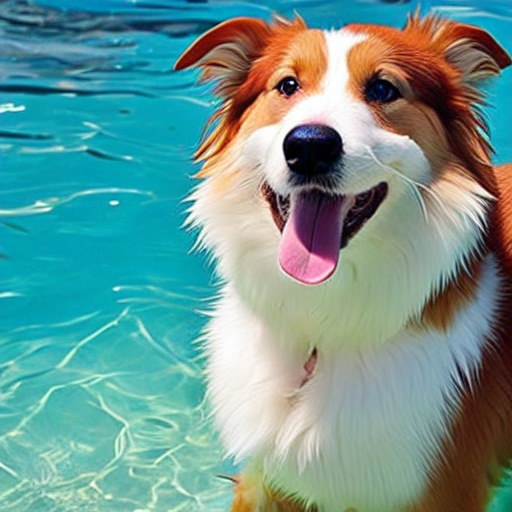

In [3]:
from PIL import Image
from IPython.display import display # For displaying image in Colab
import os
# Assuming blip_diffusion_pipe is already loaded from a previous cell
# e.g.:
# from diffusers import BlipDiffusionPipeline
# import torch
# blip_diffusion_pipe = BlipDiffusionPipeline.from_pretrained(
#     "Salesforce/blipdiffusion", torch_dtype=torch.float16 # or your preferred dtype
# ).to("cuda") # or "cpu"

# --- HARD-CODED FILENAMES ---
# Make sure these EXACTLY match the names of the files you uploaded to Colab's /content/ directory
conditional_image_filename = "dog.png"
# The Hugging Face example provided doesn't use a separate reference_image for object styling in this specific call.
# It focuses on editing/generating based on the conditional image and subject prompts.
# If you want to use the 'shein-jacket.jpg' for styling, that requires the other call signature with 'reference_image'.
# For now, we'll stick to the example's structure which only uses one input image.

# --- Conditional Image Loading (from hard-coded local Colab file) ---
cond_image_pil = None # This will be our PIL Image object for the conditional image
if os.path.exists(conditional_image_filename):
    print(f"Loading conditional image from local file: {conditional_image_filename}")
    try:
        original_cond_image = Image.open(conditional_image_filename)
        print(f"Conditional image opened. Mode: {original_cond_image.mode}, Size: {original_cond_image.size}")
        # Convert to RGB, handling RGBA or Palette if necessary
        if original_cond_image.mode == 'RGBA':
            cond_image_pil = Image.new("RGB", original_cond_image.size, (255, 255, 255))
            cond_image_pil.paste(original_cond_image, mask=original_cond_image.split()[3])
        elif original_cond_image.mode == 'P':
            temp_rgba_image = original_cond_image.convert('RGBA')
            cond_image_pil = Image.new("RGB", temp_rgba_image.size, (255, 255, 255))
            cond_image_pil.paste(temp_rgba_image, mask=temp_rgba_image.split()[3])
        else:
            cond_image_pil = original_cond_image.convert('RGB')
        print("Conditional image processed and converted to RGB successfully.")
    except Exception as e:
        print(f"An unexpected error occurred while loading/processing conditional image '{conditional_image_filename}': {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"Conditional image file '{conditional_image_filename}' NOT FOUND in Colab session. Please upload it.")


# --- Proceed with generation if image and pipeline are loaded ---
if 'blip_diffusion_pipe' not in locals() or blip_diffusion_pipe is None:
    print("\nError: `blip_diffusion_pipe` is not loaded. Please load the pipeline first.")
elif cond_image_pil: # We only need the conditional image for this example structure
    print("\nProceeding with image generation (Hugging Face example style)...")

    # Inputs based on the Hugging Face example
    cond_subject = "dog"  # Subject in your conditional image (dog.png)
    tgt_subject = "dog"   # What the subject should be in the output
    # Prompt describing the desired output scene for the target subject
    text_prompt_input = "a dog swimming underwater"
    # Or, if you want the dog to wear the jacket (but without explicit style transfer from a ref_image):
    # text_prompt_input = "a photo of a dog wearing a shein jacket"

    guidance_scale = 7.5
    num_inference_steps = 25 # As per HF example, can be increased
    # Using 'negative_prompt' which is more standard than 'neg_prompt' for recent diffusers
    negative_prompt = "over-exposure, under-exposure, saturated, duplicate, out of frame, lowres, cropped, worst quality, low quality, jpeg artifacts, morbid, mutilated, out of frame, ugly, bad anatomy, bad proportions, deformed, blurry, duplicate"

    print("Generating image... This might take a moment.")
    try:
        # Call structure based on the Hugging Face example:
        # output = blip_diffusion_pipe(prompt, cond_image, cond_subject, tgt_subject, ...)
        output = blip_diffusion_pipe(
            text_prompt_input,        # The overall prompt
            cond_image_pil,           # The PIL.Image object for the conditional image
            cond_subject,             # String: subject in the conditional image
            tgt_subject,              # String: subject in the target image
            guidance_scale=guidance_scale,
            num_inference_steps=num_inference_steps,
            neg_prompt=negative_prompt, # Use 'negative_prompt'
            height=512,
            width=512,
        ).images[0] # Access the first image from the 'images' list in the output

        print("Displaying generated image.")
        display(output) # output is already the PIL image

    except TypeError as te:
        print(f"TypeError during image generation: {te}")
        print("This usually means the arguments passed to the pipeline call are incorrect for your diffusers version, even when following the example.")
        print("Please double-check the BlipDiffusionPipeline.__call__ signature for your exact diffusers version or check for updated examples.")
        import inspect
        print("\nTo help debug, here's the (approximated) expected signature:")
        try:
            actual_call_method = blip_diffusion_pipe.__call__
            if hasattr(actual_call_method, "__wrapped__"): actual_call_method = actual_call_method.__wrapped__
            sig = inspect.signature(actual_call_method)
            print(sig)
        except Exception as inspect_e:
            print(f"Could not inspect signature: {inspect_e}")
    except Exception as e:
        print(f"Error during image generation: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\nCannot proceed with generation.")
    if not ('blip_diffusion_pipe' in locals() and blip_diffusion_pipe is not None):
        print("- Pipeline not loaded.")
    if not cond_image_pil:
        print("- Conditional image (dog.png) failed to load or was not found.")